<a href="https://colab.research.google.com/github/jaison-leonardo/projects-ML-DL-iue/blob/main/Algoritmo_genetico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
from statistics import mean
random.seed(42)

In [12]:
# Datos: Objetos de la mochila
items = [
    {"nombre": "Laptop",   "peso": 3, "valor": 9},
    {"nombre": "Camara",   "peso": 2, "valor": 6},
    {"nombre": "Libro",    "peso": 1, "valor": 3},
    {"nombre": "Botella",  "peso": 2, "valor": 4},
    {"nombre": "Audifonos","peso": 1, "valor": 2},
    {"nombre": "Tablet",   "peso": 4, "valor": 8},
]

peso_maximo = 7
n = len(items)

In [11]:
# Función objetivo, penaliza los cromosomas dependiendo de su peso
def fitness(chromosome):
    peso = sum(gene * items[i]["peso"] for i, gene in enumerate(chromosome))
    valor = sum(gene * items[i]["valor"] for i, gene in enumerate(chromosome))
    if peso > peso_maximo:
        return 0
    return valor

In [10]:
# Generación de los individuos de forma aleatoria
def generar_individuo():
    return [random.randint(0, 1) for _ in range(n)]

# selecciona el mejor comparando aleatoriamente
def torneo(poblacion, k=3):
    candidatos = random.sample(poblacion, k)
    candidatos.sort(key=fitness, reverse=True)
    return candidatos[0]

# Mezcla los padres en un punto para generar hijos
def crossover(p1, p2):
    punto = random.randint(1, n - 1)
    h1 = p1[:punto] + p2[punto:]
    h2 = p2[:punto] + p1[punto:]
    return h1, h2

# Introduce la variación para mutar los genes
def mutar(individuo, tasa=0.1):
    for i in range(len(individuo)):
        if random.random() < tasa:
            individuo[i] = 1 - individuo[i]
    return individuo

In [6]:
tam_poblacion = 30
generaciones = 60
tasa_mutacion = 0.08
poblacion = [generar_individuo() for _ in range(tam_poblacion)]

hist_mejor = []
hist_promedio = []

In [9]:
for gen in range(generaciones):
    poblacion.sort(key=fitness, reverse=True)

    # Registrar métricas
    fitness_vals = [fitness(ind) for ind in poblacion]
    hist_mejor.append(max(fitness_vals))
    hist_promedio.append(sum(fitness_vals) / len(fitness_vals))

    nueva = poblacion[:2]  # elitismo, se queda con los dos mejores

    while len(nueva) < tam_poblacion:
        padre1 = torneo(poblacion)
        padre2 = torneo(poblacion)
        hijo1, hijo2 = crossover(padre1, padre2)

        nueva.append(mutar(hijo1[:], tasa_mutacion))
        if len(nueva) < tam_poblacion:
            nueva.append(mutar(hijo2[:], tasa_mutacion))

    poblacion = nueva

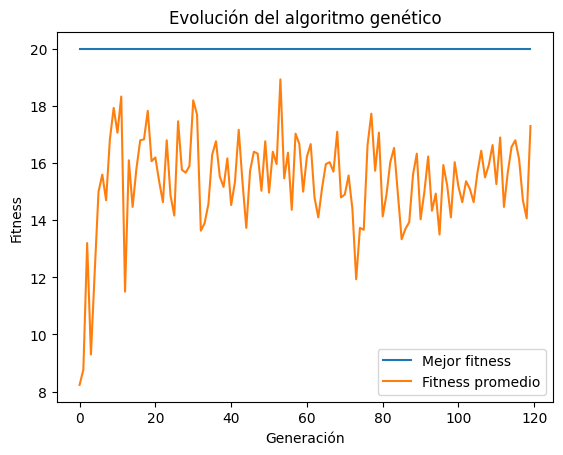

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(hist_mejor, label="Mejor fitness")
plt.plot(hist_promedio, label="Fitness promedio")

plt.xlabel("Generación")
plt.ylabel("Fitness")
plt.title("Evolución del algoritmo genético")
plt.legend()

plt.show()